# Seminars 7&8

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [ ]:
!wget https://raw.githubusercontent.com/Majid-Sohrabi/MLDM-2025/refs/heads/main/01-intro/train.csv
df = pd.read_csv("train.csv")
df.head()

--2025-10-24 15:21:12--  https://raw.githubusercontent.com/Majid-Sohrabi/MLDM-2025/refs/heads/main/01-intro/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘train.csv.3’

train.csv.3         100%[===================>]  58.89K  --.-KB/s    in 0.001s  

2025-10-24 15:21:12 (39.8 MB/s) - ‘train.csv.3’ saved [60302/60302]



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Measures of spread

Measures of spread:

* Range
* Interquartile range
* Variance
* Standard deviation

### Range

Range is the difference between the largest and smallest values

In [ ]:
df['Age'].max() - df['Age'].min(), df['Fare'].max() - df['Fare'].min()

(79.58, 512.3292)

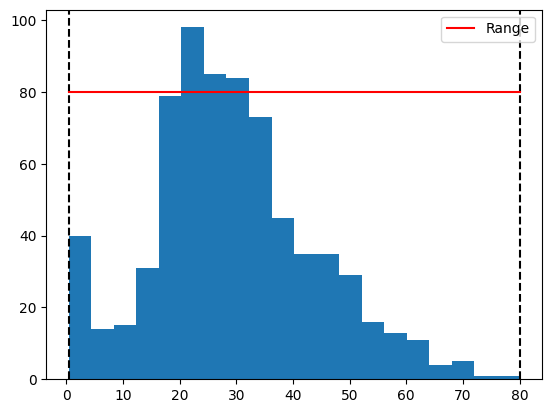

In [ ]:
#Histogram of Age
plt.hist(df['Age'], bins=20)

#Dashed lines near min and max
plt.axvline(df['Age'].min(), linestyle='--', c='black')
plt.axvline(df['Age'].max(), linestyle='--', c='black')

plt.plot([df['Age'].min(), df['Age'].max()], [80, 80], c='red', label='Range')

plt.legend(loc='upper right')
plt.show()

In [ ]:
#Example:

#Sample 99 times 1 and 1 time 1000
sample = np.ones(100)
sample[0] = 1000

In [ ]:
sample

array([1000.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,
          1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,
          1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,
          1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,
          1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,
          1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,
          1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,
          1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,
          1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,
          1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,
          1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,
          1.])

In [ ]:
sample.max() - sample.min()

np.float64(999.0)

### Interquartile range

Quartiles are values which divide the number of data points into four parts(quarters), of more-or-less equal size:




*   The first quartile (Q1) - lowest 25% data is below this point. It is also known as the lower quartile.
*   The second quartile (Q2) is the median of a data set; thus 50% of the data lies below this point.
* The third quartile (Q3) - lowest 75% data is below this point. It is known as the upper quartile, as 75% of the data lies below this point.






In [ ]:
df['Age'].quantile(0.25) #q1

np.float64(20.125)

In [ ]:
df['Age'].quantile(0.5) #q2

np.float64(28.0)

In [ ]:
df['Age'].quantile(0.75) #q3

np.float64(38.0)

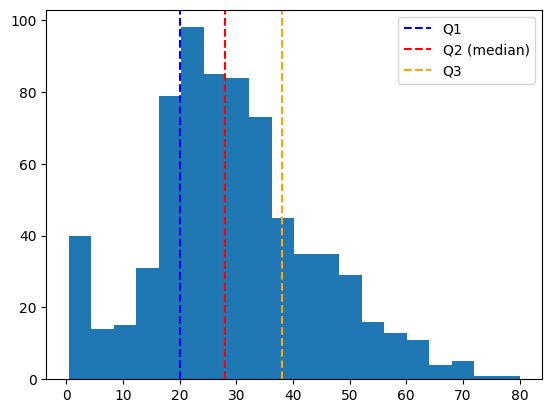

In [ ]:
#Histogram of Age
plt.hist(df['Age'], bins=20)

#Dashed lines Q1, Q2, Q3
plt.axvline(df['Age'].quantile(0.25), linestyle='--', c='blue',   label='Q1')
plt.axvline(df['Age'].quantile(0.50), linestyle='--', c='red',    label='Q2 (median)')
plt.axvline(df['Age'].quantile(0.75), linestyle='--', c='orange', label='Q3')


plt.legend(loc='upper right')
plt.show()

In [ ]:
np.quantile(sample, 0.25), np.quantile(sample, 0.5), np.quantile(sample, 0.75)

(np.float64(1.0), np.float64(1.0), np.float64(1.0))

Interquartile range -  difference between the third and fist quartile of the data.

IQR = Q3 - Q1

In [ ]:
df['Age'].quantile(0.75)-df['Age'].quantile(0.25)

np.float64(17.875)

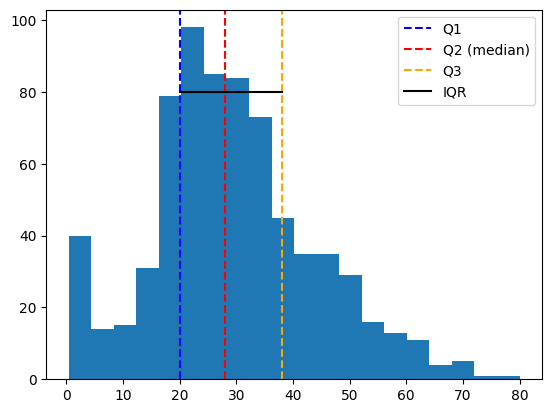

In [ ]:
#Histogram of Age
plt.hist(df['Age'], bins=20)

#Dashed lines Q1, Q2, Q3
plt.axvline(df['Age'].quantile(0.25), linestyle='--', c='blue',   label='Q1')
plt.axvline(df['Age'].quantile(0.50), linestyle='--', c='red',    label='Q2 (median)')
plt.axvline(df['Age'].quantile(0.75), linestyle='--', c='orange', label='Q3')


plt.plot([df['Age'].quantile(0.25), df['Age'].quantile(0.75)], [80, 80], c='black', label='IQR')

plt.legend(loc='upper right')
plt.show()

In [ ]:
np.quantile(sample, 0.75) - np.quantile(sample, 0.25)

np.float64(0.0)

### Variance `.var()`

Variance is the expected value of the squared variation of a random variable from its mean value



Variance for population differ from variance for sample:

Eample:

data  - 1 2 5 3 3 1

The mean value = 2.5

The sum of squared deviations = (2.25 + 0.25 + 6.25 + 0.25 + 0.25 + 2.25) = 11.5

If the data is the population, var = 11.5 / 6 = 1.92

If the data is a sample, var = 11.5 / (6 - 1) = 2.3

In [ ]:
#population
df['Age'].var(ddof=0)

210.7235797536662

In [ ]:
#sample
df['Age'].var(ddof=1)

211.0191247463081

In [ ]:
#the default is for sample (ddof=1)
df['Age'].var()

211.0191247463081

In [ ]:
#in numpy ddof=0 by default
sample.var(), sample.var(ddof=1)

(np.float64(9880.209899999998), np.float64(9980.009999999998))

### Standard deviation `.std()`

Standard deviation is the square root of variance.

In [ ]:
#population
df['Age'].std(ddof=0)

14.516321150817317

In [ ]:
#sample
df['Age'].std(ddof=1)

14.526497332334044

In [ ]:
sample.std(), sample.std(ddof=1)

(np.float64(99.39924496695133), np.float64(99.89999999999999))

Standard deviation is more useful to describe the variability because it is expressed in the same units as the data. Variance is often used in mathematics.

**Task**  What was the standard deviation of age of male/female passengers?

In [ ]:
#your code here
df[df['Sex'] == 'female']['Age'].std(), df[df['Sex'] == 'male']['Age'].std()

(14.110146457544134, 14.678200823816601)

**Task** Compute the range and IQR for Fare. Make conclusions.

In [ ]:
#your code here
df['Fare'].max() - df['Fare'].min(), df['Fare'].quantile(0.75) - df['Fare'].quantile(0.25)

(512.3292, np.float64(23.0896))

## Outliers

Outlier is a data point that stands out a lot from the other data points in a set.

Possible causes:
*   Variability of data
*   Novel data
*   Errors

Examples:

* The average height of a giraffe is $\sim16$ feet tall. There are 2 giraffes that are 9 and 8.5 feet tall.
* T-shirts usually cost from 10 \\$ to 1 000 \\$, one T-shirt costs 1 000 000 \\$ because it is a luxury item created by a famous designer.
* The age of a student is 1020 years. They made a mistake while filling the year of birth in the form:  typed 1004 instead of 2004.



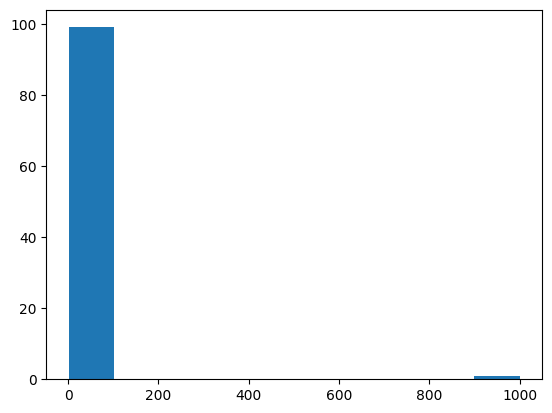

In [ ]:
#on histogram we have 1 tall bar and 1 really short one
plt.hist(sample)
plt.show()

<Axes: xlabel='Fare', ylabel='Count'>

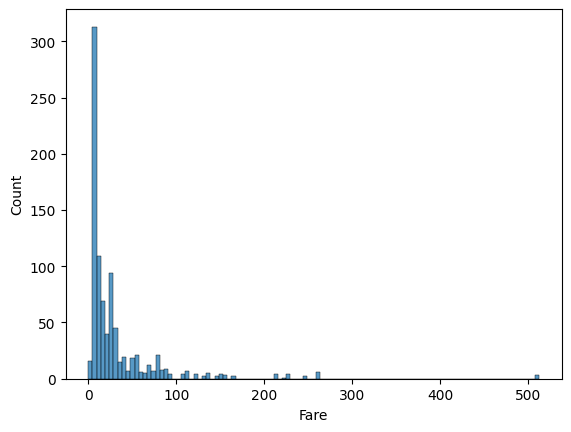

In [ ]:
sns.histplot(df['Fare'])

There are 2 common ways to spot outliers:


*   1.5IQR
*   std; 2std; 3std



### 1.5IQR

Outliers are points below $Q1-1.5IQR$ and above $Q3+1.5IQR$

This boxplot may be useful:
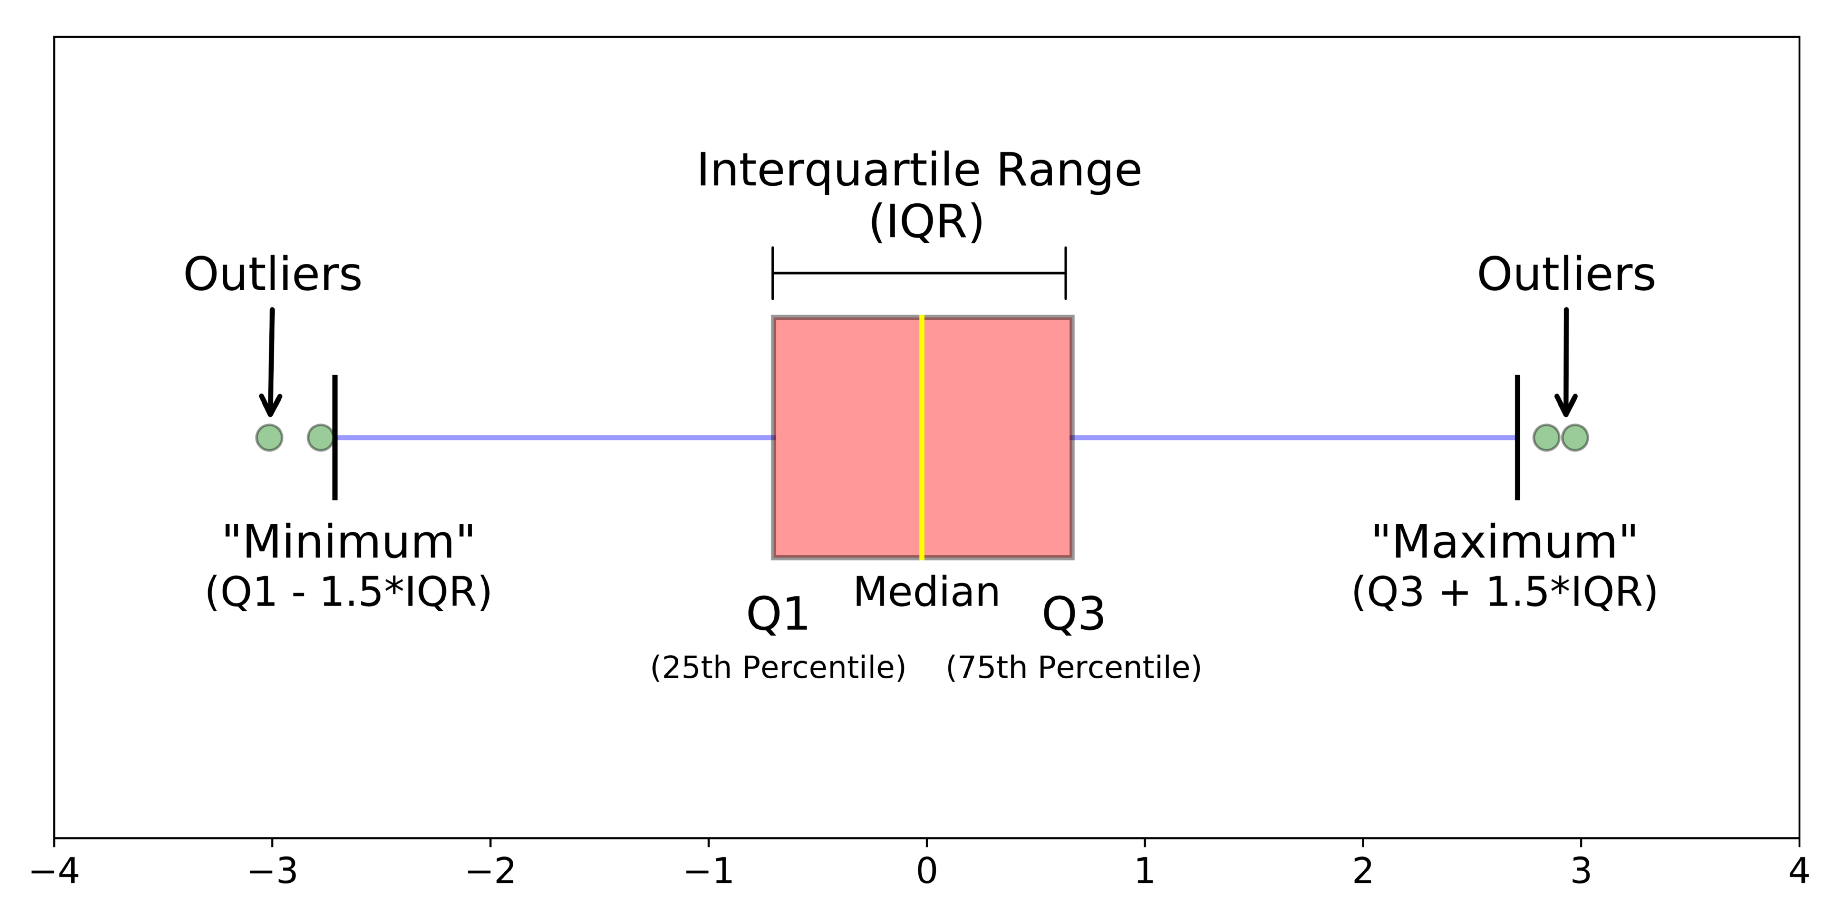

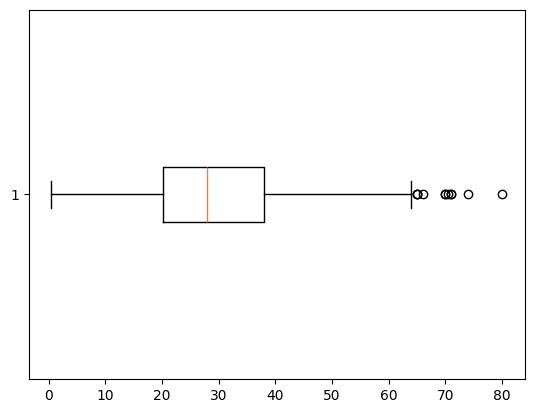

In [ ]:
plt.boxplot(df['Age'].dropna(), vert=False)
plt.show()

<Axes: xlabel='Age'>

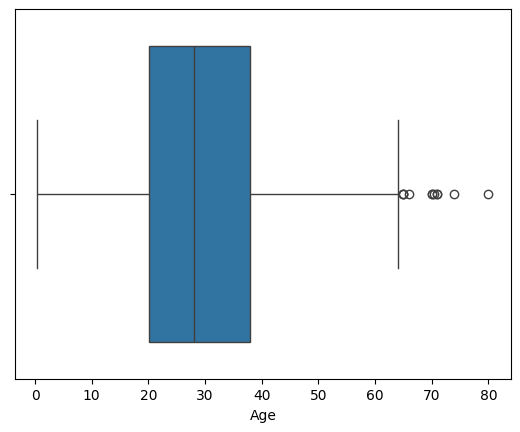

In [ ]:
sns.boxplot(df, x='Age')

In [ ]:
q1 = df['Age'].quantile(0.25)
q3 = df['Age'].quantile(0.75)
iqr = q3 - q1

low_iqr = q1 - iqr * 1.5
up_iqr = q3 + iqr * 1.5

low_iqr, up_iqr

(np.float64(-6.6875), np.float64(64.8125))

**Task** Filter the outliers

In [ ]:
#your code here
df[(df['Age'] < low_iqr) | (df['Age'] > up_iqr)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
280,281,0,3,"Duane, Mr. Frank",male,65.0,0,0,336439,7.7500,NaN,Q
456,457,0,1,"Millet, Mr. Francis Davis",male,65.0,0,0,13509,26.5500,E38,S
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S


### std; 2std; 3std

For normal distribution with  $μ=0$  and variance  $σ^2$:

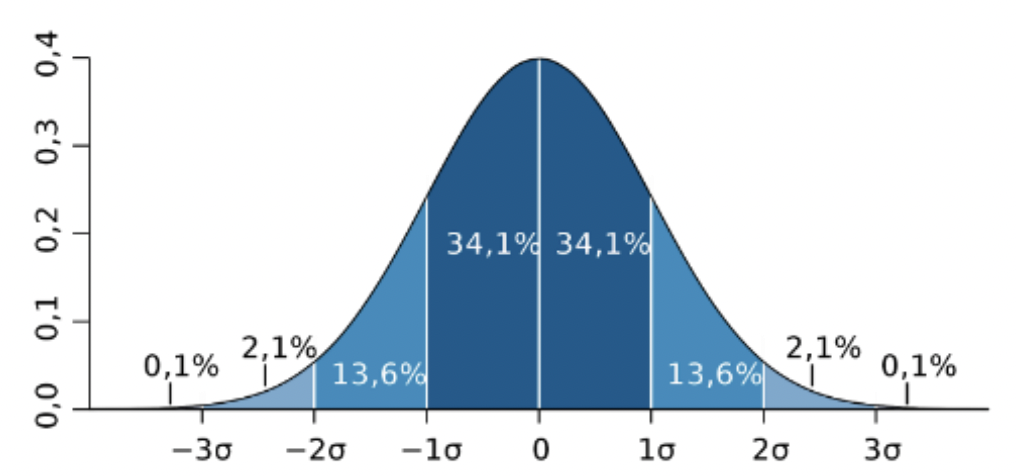

So, if the distribution is normal:



*   We consider 1 $\sigma$: NOT outliers are 68.2\% of data near center ($\mu$)
*   We consider 2$\sigma$: NOT outliers are 95.5\% of data near center ($\mu$)
*   We consider 3$\sigma$: NOT outliers are 99.7\% of data near center ($\mu$)



In [ ]:
mu = df['Age'].mean()
mu

np.float64(29.69911764705882)

In [ ]:
std = df['Age'].std()
std

14.526497332334044

In [ ]:
low_1s = mu - 1 * std
up_1s = mu + 1 * std

low_2s = mu - 2 * std
up_2s = mu + 2 * std

low_3s = mu - 3 * std
up_3s = mu + 3 * std

low_2s, up_2s

(np.float64(0.6461229823907324), np.float64(58.752112311726904))

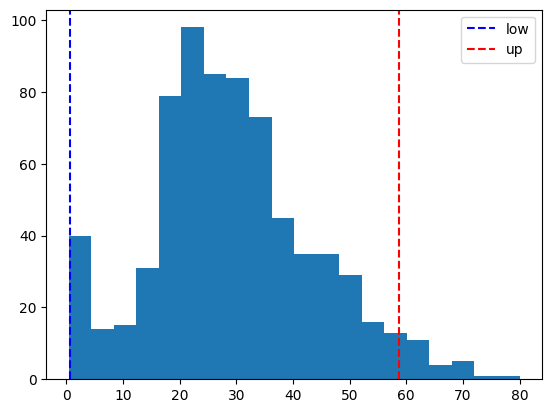

In [ ]:
#Histogram of Age
plt.hist(df['Age'], bins=20)


plt.axvline(low_2s, linestyle='--', c='blue',   label='low')
plt.axvline(up_2s,  linestyle='--', c='red',    label='up')


plt.legend(loc='upper right')
plt.show()

**Task** Filter the outliers

In [ ]:
#your code here
df[(df['Age'] < low_2s) | (df['Age'] > up_2s)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.00,0,0,C.A. 24579,10.5000,NaN,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.00,0,1,113509,61.9792,B30,C
94,95,0,3,"Coxon, Mr. Daniel",male,59.00,0,0,364500,7.2500,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.00,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.50,0,0,370369,7.7500,NaN,Q
170,171,0,1,"Van der hoef, Mr. Wyckoff",male,61.00,0,0,111240,33.5000,B19,S
232,233,0,2,"Sjostedt, Mr. Ernst Adolf",male,59.00,0,0,237442,13.5000,NaN,S
252,253,0,1,"Stead, Mr. William Thomas",male,62.00,0,0,113514,26.5500,C87,S
275,276,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.00,1,0,13502,77.9583,D7,S
280,281,0,3,"Duane, Mr. Frank",male,65.00,0,0,336439,7.7500,NaN,Q


## Comparison

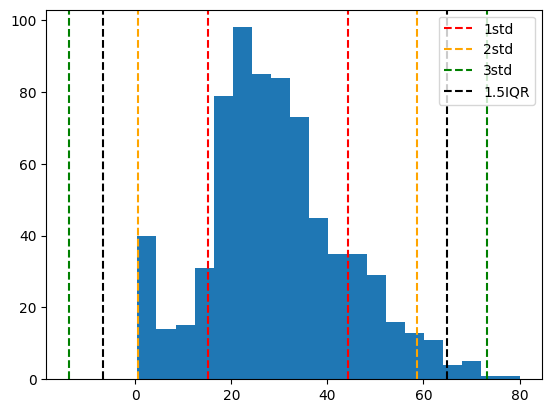

In [ ]:
#Histogram of Age
plt.hist(df['Age'], bins=20)


plt.axvline(low_1s, linestyle='--', c='red',   label='1std')
plt.axvline(up_1s,  linestyle='--', c='red')


plt.axvline(low_2s, linestyle='--', c='orange',   label='2std')
plt.axvline(up_2s,  linestyle='--', c='orange')

plt.axvline(low_3s, linestyle='--', c='green',   label='3std')
plt.axvline(up_3s,  linestyle='--', c='green')


plt.axvline(low_iqr, linestyle='--', c='black',   label='1.5IQR')
plt.axvline(up_iqr,  linestyle='--', c='black')


plt.legend(loc='upper right')
plt.show()

**Task** Find the outliers for Fare using 2std.

In [ ]:
#your code here

up_fare  = df['Fare'].mean() + 2 * df['Fare'].std()
low_fare = df['Fare'].mean() - 2 * df['Fare'].std()

df[(df['Fare'] < low_fare) | (df['Fare'] > up_fare)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.00,3,2,19950,263.0000,C23 C25 C27,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.00,3,2,19950,263.0000,C23 C25 C27,S
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.00,0,1,PC 17558,247.5208,B58 B60,C
195,196,1,1,"Lurette, Miss. Elise",female,58.00,0,0,PC 17569,146.5208,B80,C
258,259,1,1,"Ward, Miss. Anna",female,35.00,0,0,PC 17755,512.3292,NaN,C
268,269,1,1,"Graham, Mrs. William Thompson (Edith Junkins)",female,58.00,0,1,PC 17582,153.4625,C125,S
269,270,1,1,"Bissette, Miss. Amelia",female,35.00,0,0,PC 17760,135.6333,C99,S
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S
299,300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.00,0,1,PC 17558,247.5208,B58 B60,C


## Missing values

Which columns have missing values (`NaN`)

In [ ]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Sorted for easier work:

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


Why missing data is a problem?

*   Reduce sample size
*   Introduce bias
*   Impossible to apply machine learning techniques

Why data may be missing?

*   Errors
*   Non-response (privacy concerns, conditional missingness)
*   Nature of the variable

Examples:

*   Technical issues
*   Questions in the form: "Your patronymic", "Your middle name", follow-up questions like "If you answered 'yes' in the previous question, write down your e-mail"
*   Variable PREVIOUS_CARD_NUM_UTILIZED: the number of already recycled cards (if empty - 0)







Possible ways to tackle:


*   Fill the missing values (the usual approach)
*   Delete the feature if there are a lot of (usually $> 40\%$) missing values. (Need to be cautious, need to check the nature of the missing data, may limit ourselves)
*   Delete the samples with missing values (if the sample is big)




In [ ]:
df.isna().mean().sort_values(ascending=False)

,0
Cabin,0.771044
Age,0.198653
Embarked,0.002245
PassengerId,0.000000
Name,0.000000
Pclass,0.000000
Survived,0.000000
Sex,0.000000
Parch,0.000000
SibSp,0.000000


`Cabin` seems to be missing 77\% data. We need to investigate, why. Maybe, there were no cabins in particular class? Or the cabins were not assigned and it is unknown who chose which?

In [ ]:
df['No_Cabin'] = df['Cabin'].isna().astype(int)
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,No_Cabin
66,67,1,2,"Nye, Mrs. (Elizabeth Ramell)",female,29.0,0,0,C.A. 29395,10.5000,F33,S,0
251,252,0,3,"Strom, Mrs. Wilhelm (Elna Matilda Persson)",female,29.0,1,1,347054,10.4625,G6,S,0
323,324,1,2,"Caldwell, Mrs. Albert Francis (Sylvia Mae Harb...",female,22.0,1,1,248738,29.0000,NaN,S,1


In [ ]:
df.groupby('Pclass')['No_Cabin'].mean()

,No_Cabin
Pclass,
1,0.185185
2,0.913043
3,0.975560


For 3 and 2 class in the majority of cases there was no assigned cabin

Also, there are a lot of unique values:

In [ ]:
df['Cabin'].value_counts()

,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
...,...
E17,1
A24,1
C50,1


In [ ]:
np.percentile(df['Cabin'].value_counts(), 0.75)

np.float64(1.0)

All in all, cabin feature is cathegorical, missing in majority of cases, align with Pclass and has a lot of unique values. It may be almost impossible to work with it properly. Let's drop this column.

In [ ]:
df.drop('Cabin', axis=1, inplace=True)

Let's work with `Embarked` and `Age`. There are not many missing values, let's fill them.


What can we use:


*   Measures of Central Tendency for the whole sample
*   Measures of Central Tendency for the group
*   Random element



For `Age` we can use mean, median or mode. Let's use median.

In [ ]:
age_with_nan = df['Age'].copy()

In [ ]:
age_with_nan.median()

28.0

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())

`Embarked` is not numeric, so we can use only mode

In [ ]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

Let's check if there are any missing values now

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


When we investigated the measures of central tendency for `Age` we ignored `NaN` values.

It is better to fill missing values afterwards, because we may get some strange results. Let's look into the histogram of `Age` again.

What is going on?

<Axes: xlabel='Age', ylabel='Count'>

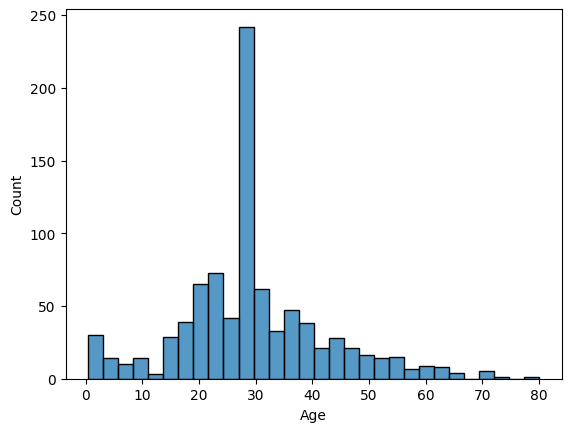

In [ ]:
sns.histplot(df, x='Age')

## Quantiles, Percentiles

We used quartiles (0.25, 0.5, 0.75 quantiles)

In [ ]:
df['Fare'].quantile(0.95)

np.float64(112.07915)

In [ ]:
np.percentile(df['Fare'], 95)

np.float64(112.07915)

In [ ]:
np.quantile(df['Fare'], 0.95)

np.float64(112.07915)

**Task** Compute the number and the proportion of the passengers who have Fare more than the 90-percentile. Does it agree with the theory?

In [ ]:
#your code here
df[df['Fare'] > np.percentile(df['Fare'], 90)].shape[0] / df.shape[0]

0.09764309764309764

## Z-score

In [ ]:
from scipy.stats import zscore

z_scores_age = zscore(age_with_nan[~age_with_nan.isna()])
z_scores_age

array([-0.53037664,  0.57183099, -0.25482473,  0.36516706,  0.36516706,
        1.67403863, -1.90813618, -0.18593675, -1.08148046, -1.77036023,
        1.94959054, -0.6681526 ,  0.64071897, -1.08148046,  1.74292661,
       -1.90813618,  0.08961515,  0.36516706,  0.29627909, -1.01259248,
       -0.11704878, -1.49480832,  0.57183099, -0.73704057,  0.70960695,
        2.50069435, -0.11704878,  0.8473829 , -0.59926462, -0.80592855,
       -1.08148046,  0.70960695, -0.18593675, -1.83924821, -0.73704057,
       -0.80592855, -1.5636963 , -0.59926462,  1.32959874, -0.0481608 ,
        2.43180638, -0.59926462, -0.08260479, -1.70147225, -1.28814439,
       -0.53037664,  0.57183099,  1.05404683, -1.77036023, -0.0481608 ,
       -0.73704057, -0.87481653, -0.25482473,  0.15850313, -0.9437045 ,
       -0.59926462, -0.25482473,  0.15850313, -0.32371271, -1.98873512,
        0.02072718, -0.53037664, -0.0481608 , -0.11704878, -0.87481653,
        0.22739111, -0.9437045 , -0.46148866, -0.39260069, -0.04

In [ ]:
zscore(sample)

array([ 9.94987437, -0.10050378, -0.10050378, -0.10050378, -0.10050378,
       -0.10050378, -0.10050378, -0.10050378, -0.10050378, -0.10050378,
       -0.10050378, -0.10050378, -0.10050378, -0.10050378, -0.10050378,
       -0.10050378, -0.10050378, -0.10050378, -0.10050378, -0.10050378,
       -0.10050378, -0.10050378, -0.10050378, -0.10050378, -0.10050378,
       -0.10050378, -0.10050378, -0.10050378, -0.10050378, -0.10050378,
       -0.10050378, -0.10050378, -0.10050378, -0.10050378, -0.10050378,
       -0.10050378, -0.10050378, -0.10050378, -0.10050378, -0.10050378,
       -0.10050378, -0.10050378, -0.10050378, -0.10050378, -0.10050378,
       -0.10050378, -0.10050378, -0.10050378, -0.10050378, -0.10050378,
       -0.10050378, -0.10050378, -0.10050378, -0.10050378, -0.10050378,
       -0.10050378, -0.10050378, -0.10050378, -0.10050378, -0.10050378,
       -0.10050378, -0.10050378, -0.10050378, -0.10050378, -0.10050378,
       -0.10050378, -0.10050378, -0.10050378, -0.10050378, -0.10

**Task** Choose the person with the most extreme age.

In [ ]:
#your code here

df[df['Age'] == age_with_nan[~age_with_nan.isna()].iloc[np.fabs(z_scores_age).argmax()]]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,No_Cabin
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0,S,0


We can recompute measures of central tendency. What can be said about them?

In [ ]:
np.mean(z_scores_age)

np.float64(2.338621049070358e-16)

In [ ]:
np.median(z_scores_age)

np.float64(-0.11704877767623337)

In [ ]:
def mode(sample):
  values, counts = np.unique(sample, return_counts=True)
  return values[counts.argmax()]

mode(z_scores_age)

np.float64(-0.3926006863479967)

Measures of variability/spread. What can you notice?

In [ ]:
z_scores_age.max() - z_scores_age.min()

np.float64(5.482105223024732)

In [ ]:
np.quantile(z_scores_age, 0.75) - np.quantile(z_scores_age, 0.25)

np.float64(1.2313725918769425)

In [ ]:
z_scores_age.var()

np.float64(1.0)

In [ ]:
z_scores_age.std()

np.float64(1.0)

Why is it useful?

How did the distribution changed?

<Axes: xlabel='Age', ylabel='Count'>

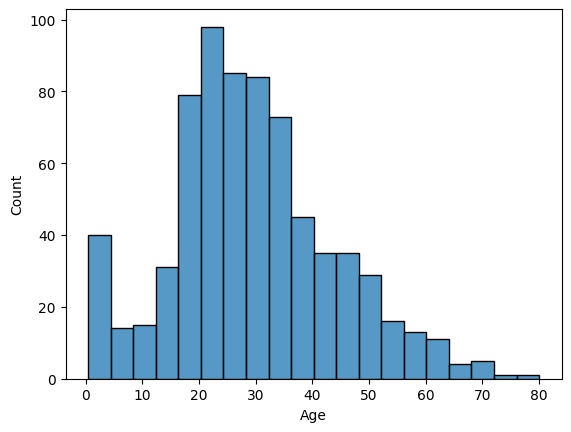

In [ ]:
sns.histplot(age_with_nan)

<Axes: ylabel='Count'>

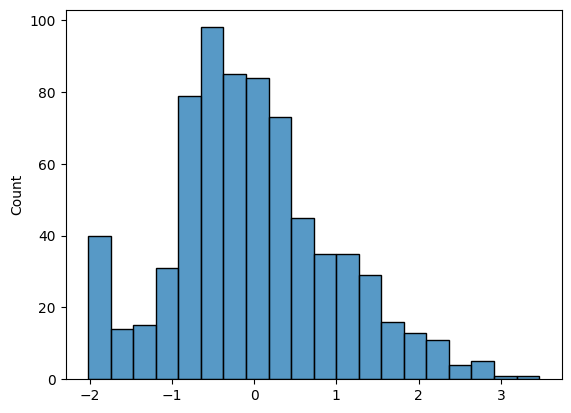

In [ ]:
sns.histplot(z_scores_age)

We actualy can try comparing different features/distributions:

The age 80 is an outlier. And Fare 512, too. Which one is "worse"?

Are distribution of Age and Fare similar?

In [ ]:
df['Age'].max(), df['Fare'].max()

(80.0, 512.3292)

We may try to compare them on one plot, but the scales are vastly different.

<Axes: xlabel='Fare', ylabel='Count'>

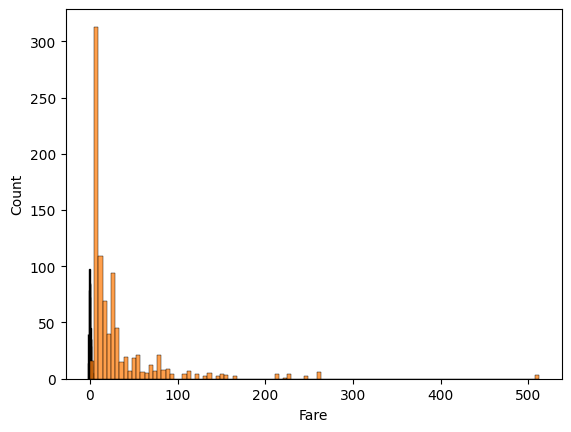

In [ ]:
sns.histplot(z_scores_age, label='Age')
sns.histplot(df['Fare'], label='Fare')

<Axes: ylabel='Count'>

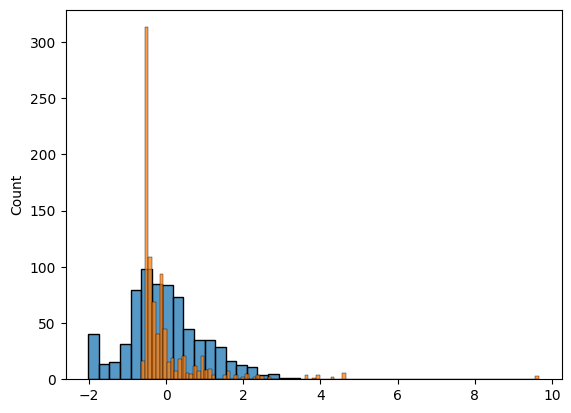

In [ ]:
z_scores_fare = zscore(df['Fare'])

sns.histplot(z_scores_age, label='Age')
sns.histplot(z_scores_fare, label='Fare')

Let's check the outliers.

**Task** Choose the Z-score (age) for the people of age 80 and Z-score (fare) for people who paid 512.3292 Compare the results

In [ ]:
#your code here
z_scores_age[age_with_nan.dropna() == 80], z_scores_fare[df['Fare'] == 512.3292]

(array([3.46512604]), array([9.66716653, 9.66716653, 9.66716653]))

## Hypothesis testing

Algorithm:



*   Formulate hypothesis ($H_0: \mu = 12.3$)
*   Choose the level of significance ($\alpha = 0.05$)
*   Compute the statistic ($Z_{stat} = \frac{M - \mu}{\sigma/\sqrt{n}}$)
*   Compute critical value ($Z_{crit}$) or p-value
*   Compare critical value with statistic or p-value with level of significance
*  Draw conclusions



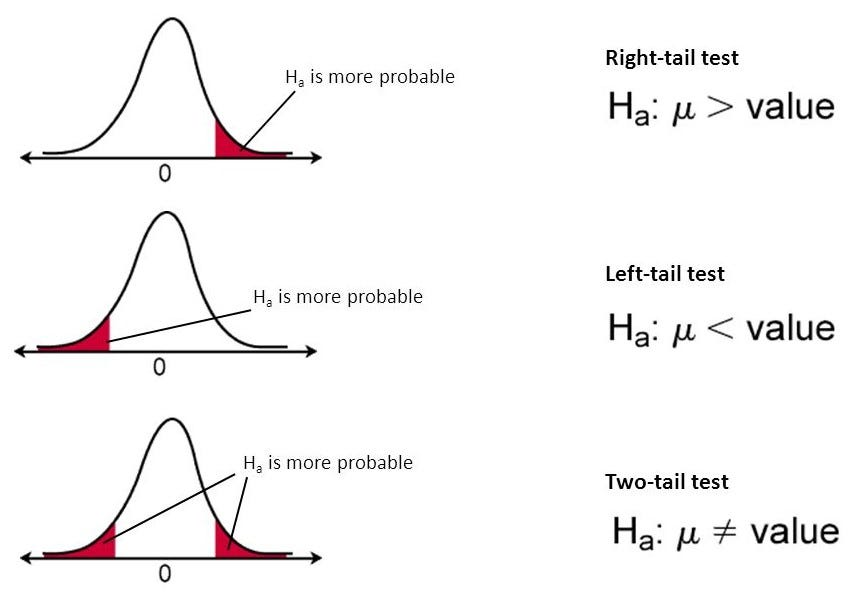

### Z-score (again)

Limitations:


*   Assume that the data has normal distribution
*   The variance of population is known



Example:
We asked 100 of HSE students: On average, how many hours do they sleep? Based on this data, we need to test the hypothesis that people sleep an average of 7 hours, given that the standard deviation of the population is 1.

In [ ]:
np.random.seed(42)

#results
n = 100
sigma = 1

#synthetic data, real avg is 7.5
hse = np.random.normal(7.5, sigma, n)

#Hypothesis
mu = 7



hse

array([7.99671415, 7.3617357 , 8.14768854, 9.02302986, 7.26584663,
       7.26586304, 9.07921282, 8.26743473, 7.03052561, 8.04256004,
       7.03658231, 7.03427025, 7.74196227, 5.58671976, 5.77508217,
       6.93771247, 6.48716888, 7.81424733, 6.59197592, 6.0876963 ,
       8.96564877, 7.2742237 , 7.5675282 , 6.07525181, 6.95561728,
       7.61092259, 6.34900642, 7.87569802, 6.89936131, 7.20830625,
       6.89829339, 9.35227818, 7.48650278, 6.44228907, 8.32254491,
       6.27915635, 7.7088636 , 5.54032988, 6.17181395, 7.69686124,
       8.23846658, 7.67136828, 7.38435172, 7.1988963 , 6.02147801,
       6.78015579, 7.03936123, 8.55712223, 7.84361829, 5.73695984,
       7.82408397, 7.11491772, 6.823078  , 8.11167629, 8.53099952,
       8.43128012, 6.66078248, 7.19078762, 7.83126343, 8.47554513,
       7.02082576, 7.31434102, 6.39366503, 6.30379338, 8.31252582,
       8.85624003, 7.42798988, 8.5035329 , 7.86163603, 6.85488025,
       7.86139561, 9.03803657, 7.46417396, 9.06464366, 4.88025

In [ ]:
M = np.mean(hse)
M #average based on the sample

np.float64(7.396153482605906)

1. Hypothesis:

$$H_0: \mu = 7$$

$$H_A: \mu \neq 7$$

2. Significance level:

$$α = 5\%$$

Alternative is two sided, so the critical values are:

In [ ]:
from scipy.stats import norm
from scipy import stats

alpha = 0.05

print(norm.ppf(alpha/2), norm.ppf(1-alpha/2))

-1.9599639845400545 1.959963984540054


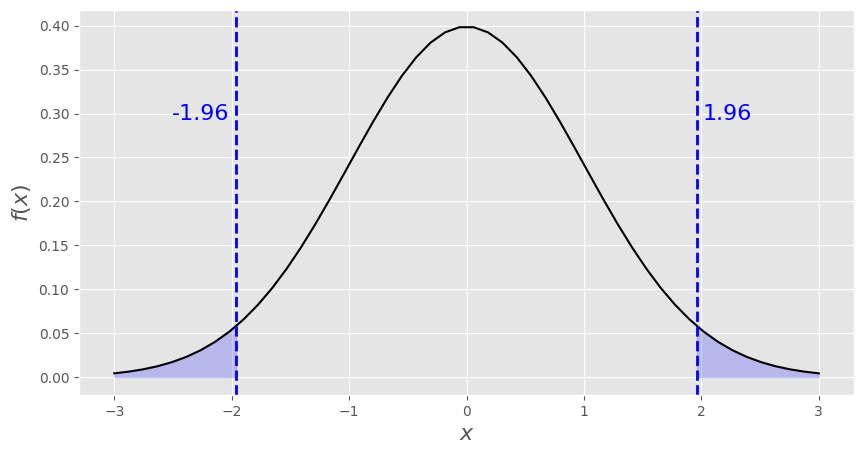

3. Compute the statistic

$$Z_{stat} = \frac{M - \mu}{\sigma / \sqrt{n}}$$

In [ ]:
Z_stat = (M - mu)/ (sigma / np.sqrt(n))
Z_stat

np.float64(3.9615348260590633)

4. Compare statistic and critical value



*   If $Z_{stat} \in [Z_{crit}^{lower}; Z_{crit}^{upper}]$, we accept $H_0$
*   Otherwise, we reject $H_0$



In [ ]:
if norm.ppf(alpha/2) <= Z_stat <= norm.ppf(1-alpha/2):
  print('accept')
else:
  print('reject')

reject


We can use `ztest` from the python library:

In [ ]:
from statsmodels.stats.weightstats import ztest as ztest
# Z-test:
#   data - sample
#   value - value for H_0
#   alternative - type of alternative hypothesis: 'two-sided', 'larger', 'smaller'


#Z_stat and p-value
result = ztest(hse, value = 7.0, alternative = 'two-sided')
result

(np.float64(4.362114673760752), np.float64(1.2881131997978336e-05))

$Z_{stat}$ is different, because the test from library does not take $\sigma$ parameter, it computes it from the sample:

In [ ]:
(M - mu)/ (hse.std(ddof=1) / np.sqrt(n))

np.float64(4.362114673760752)

What is p-value (the second number)?

p-value is the probability of obtaining test results at least as extreme as the result actually observed, under the assumption that the *null hypothesis is correct*. A very small p-value $⇒$ very unlikely outcome.

How to use it:



*   if p-value is smaller than significance level ($\alpha$), the null hypothesis is rejected
*   if p-value is greater or equal than significance level ($\alpha$), the null hypothesis is accepted



In [ ]:
if result[1] >= alpha :
  print('accept')
else:
  print('reject')

reject


Example with Titanic:

In [ ]:
df['Age'].mean()

np.float64(29.36158249158249)

Mean age seems to be really close to 30, let's check it!

1. Hypothesis:

$$H_0: \mu = 30$$

$$H_A: \mu \neq 30$$

2. Significance level:

$$α = 5\%$$

In [ ]:
ztest(df['Age'].dropna(), value = 30.0, alternative = 'two-sided')

(np.float64(21.46284347126111), np.float64(3.464543216322106e-102))

In [ ]:
if 0.143284498090153485 >= alpha :
  print('accept')
else:
  print('reject')

accept


Do we accept/reject the hypothesis?

### t score

But if we do not know the standard deviation of the population?

Let's test the same hypothesis and use same data.

$$t = \frac{M - \mu}{s/\sqrt{n}}$$

Difference from the previous: $s$ is the sample standard deviation

In [ ]:
from scipy.stats import ttest_1samp

result = ttest_1samp(a=hse, popmean=7, alternative='two-sided')
result

TtestResult(statistic=np.float64(4.362114673760752), pvalue=np.float64(3.16169731376383e-05), df=np.int64(99))

The statistic is the same, but p-value is different and there is new `df` value. This is because the distribution is different, here $t(n-1)$ is used

In [ ]:
if result[1] >= alpha :
  print('accept')
else:
  print('reject')

reject


Let's repeat the experiment with age:

In [ ]:
ttest_1samp(a = df['Age'].dropna(), popmean = 30.0, alternative = 'two-sided')

TtestResult(statistic=np.float64(-1.4636686761878148), pvalue=np.float64(0.14363758211966884), df=np.int64(890))

Do we accept/reject the hypothesis?

### Chi-square test for Independence


We have a survey and ask men and women if they drink coffee, we have the following table:


|                  |Do not drink cofee | Drink coffee  |
|------------------|---------------|------------------|
| Men | 24            | 72              |
| Women | 114           | 93              |


We want to understand if there is some relation between the variables.

Null hypothesis: no relation




In [ ]:
coffee = pd.DataFrame()
coffee['Sex'] = ['men', 'women']
coffee['Do not drink'] = [24, 114]
coffee['Drink'] = [72, 93]
coffee.set_index('Sex', inplace=True)

coffee

,Do not drink,Drink
Sex,,
men,24,72
women,114,93


In [ ]:
from scipy.stats import chi2_contingency

result = stats.chi2_contingency(coffee, correction=False)
result

Chi2ContingencyResult(statistic=np.float64(23.914383914761988), pvalue=np.float64(1.0071642033238865e-06), dof=1, expected_freq=array([[ 43.72277228,  52.27722772],
       [ 94.27722772, 112.72277228]]))

In [ ]:
if result[1] >= alpha :
  print('accept')
else:
  print('reject')

reject


Do we reject/accept the null hypothesis?

Example for Titanic: check if there is a relation between sex of the passenger amd the class:

In [ ]:
t = df.groupby('Sex')['Pclass'].value_counts().unstack()
t

Pclass,1,2,3
Sex,,,
female,94,76,144
male,122,108,347


In [ ]:
result = stats.chi2_contingency(t, correction=False)
result

Chi2ContingencyResult(statistic=np.float64(16.971499095517114), pvalue=np.float64(0.00020638864348233114), dof=2, expected_freq=array([[ 76.12121212,  64.84399551, 173.03479237],
       [139.87878788, 119.15600449, 317.96520763]]))

In [ ]:
if result[1] >= alpha :
  print('accept')
else:
  print('reject')

reject


### Pearson's chi-squared test

You may be familiar with Mendel and his experiments with pea selection: this story is perfect for illustrating the application of the chi-square test.


Let's also examine what was happening with the peas!

In Mendel's garden pea selection experiments, he observed the frequencies of different types of seeds obtained when crossing plants with round yellow seeds and plants with wrinkled green seeds. These data and the theoretical probability values, determined according to Mendel's law, are presented in the following table:

| Type of seed            | Number of seeds | Expected Mendel's probability |
|----------------------|------------------|------------------|
| Round and yellow     | 315              | 9/16             |
| Wrinkled and yellow | 101              | 3/16             |
| Round and green   | 108              | 3/16             |      
| Wrinkled and green| 32               | 1/16             |

In [ ]:
peas = pd.DataFrame()
peas["Type"] = ["Round and yellow", "Wrinkled and yellow",
                   "Round and green", "Wrinkled and green"]
peas["Number of seeds"] = [315, 101, 108, 32]
peas["Expected probability"] = [9/16, 3/16, 3/16, 1/16]
peas

,Type,Number of seeds,Expected probability
0,Round and yellow,315,0.5625
1,Wrinkled and yellow,101,0.1875
2,Round and green,108,0.1875
3,Wrinkled and green,32,0.0625


Let's compute the observed proportion:

In [ ]:
peas['Observed proportion'] = peas["Number of seeds"] / peas["Number of seeds"].sum()
peas

,Type,Number of seeds,Expected probability,Observed proportion
0,Round and yellow,315,0.5625,0.566547
1,Wrinkled and yellow,101,0.1875,0.181655
2,Round and green,108,0.1875,0.194245
3,Wrinkled and green,32,0.0625,0.057554


Null hypothesis: the observations are sampled from the expected distribution.

In [ ]:
from scipy.stats import chisquare

#f_obs - Observed frequencies in each category.
#f_exp - Expected frequencies in each category
result = chisquare(f_obs = peas['Observed proportion'],
          f_exp = peas['Expected probability'])
result

Power_divergenceResult(statistic=np.float64(0.0008453668719700503), pvalue=np.float64(0.9999934645348194))

In [ ]:
if result[1] >= alpha :
  print('accept')
else:
  print('reject')

accept


Do we reject/accept the null hypothesis?

Example with Titanic: we have 3 classes, maybe the probabilities for classes were 0.25 for first, 0.25 for second and 0.5 for third. Let's check it

In [ ]:
df['Pclass'].value_counts(normalize=True)

,proportion
Pclass,
3,0.551066
1,0.242424
2,0.206510


In [ ]:
chisquare(f_obs=df['Pclass'].value_counts(normalize=True).tolist(),
          f_exp=[0.5, 0.25, 0.25])

Power_divergenceResult(statistic=np.float64(0.013010766097185858), pvalue=np.float64(0.9935157311455944))

In [ ]:
if result[1] >= alpha :
  print('accept')
else:
  print('reject')

accept


Or maybe 0.002 for third and 0.499 for second and first?

In [ ]:
chisquare(f_obs=df['Pclass'].value_counts(normalize=True).tolist(),
          f_exp=[0.002, 0.499, 0.499])

Power_divergenceResult(statistic=np.float64(151.04022604570054), pvalue=np.float64(1.5923247350965428e-33))

### Paired samples t-test

We have 2 samples, which are related (pairs of similar units, or one group of units that has been tested twice), want to check if the $\mu$ values are the same.

Null hypothesis:two related or repeated samples have identical average (expected) values

$$
\begin{aligned}
&H_0: μ_1=μ_2 \\
&H_A: μ_1≠μ_2
\end{aligned}
$$

We asked groupmates before and after the session week (same groupmates), how long do they sleep and want to check if the average is the same

In [ ]:
np.random.seed(3)

before = np.random.normal(4.5, 1, 100)
after = before + 5 + np.random.normal(0, 0.5, 100)

In [ ]:
from scipy.stats import ttest_rel

ttest_rel(before, after)

TtestResult(statistic=np.float64(-112.7971902965604), pvalue=np.float64(2.2103507833262284e-106), df=np.int64(99))

### Independent samples t-test

2 samples that are independent, test if they have same the same $\mu$

Null hypothesis: 2 independent samples have identical average (expected) values

We asked students from HSE and MSU, how long do they sleep.

In [ ]:
np.random.seed(4)

hse = np.random.normal(7.5, 1, 100)
msu = np.random.normal(7.3, 1, 100)

In [ ]:
from scipy.stats import ttest_ind

result = stats.ttest_ind(a=hse,
                         b=msu
                         )
result

TtestResult(statistic=np.float64(1.5747213176863657), pvalue=np.float64(0.11691724956864401), df=np.float64(198.0))

In [ ]:
if result[1] >= alpha :
  print('accept')
else:
  print('reject')

accept


Example from Titanic: are the mean age of men and women differ?

In [ ]:
df.groupby('Sex')['Age'].mean()

,Age
Sex,
female,27.929936
male,30.140676


In [ ]:
result = stats.ttest_ind(a=df[df['Sex'] == 'male']['Age'].dropna(),
                b=df[df['Sex'] == 'female']['Age'].dropna()
                         )
result

TtestResult(statistic=np.float64(2.4279606481426024), pvalue=np.float64(0.015381536989875313), df=np.float64(889.0))

In [ ]:
if result[1] >= 0.05:
  print('accept')
else:
  print('reject')

reject


## Confidence interval

Confidence interval (CI) is an interval which is expected to  contain the parameter being estimated with some probability.



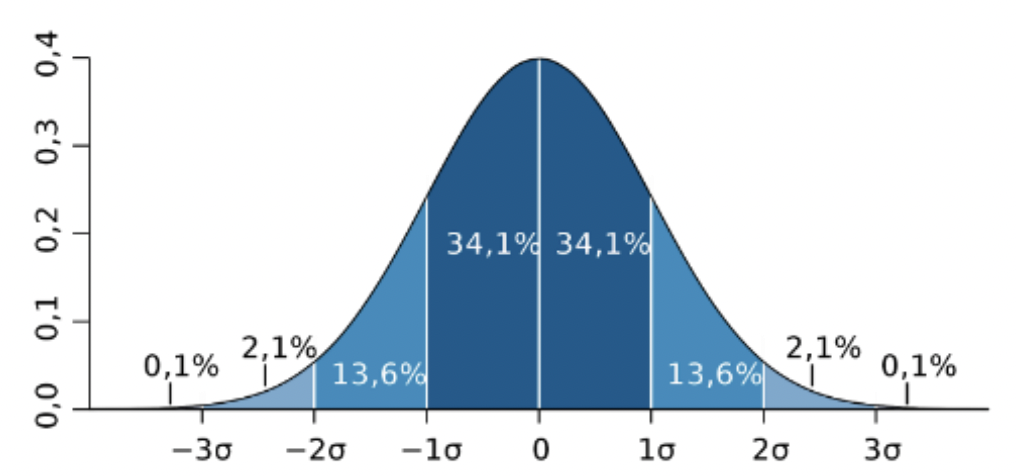

If we want to estimate the $\mu$ for a sample and we know the std ($\sigma$) of the population, we can use the formula:

$$[M -z_{\alpha/2} \frac{\sigma}{\sqrt{n}}; M + z_{\alpha/2} \frac{\sigma}{\sqrt{n}}]$$


If we do not know $\sigma$:

$$[M -t_{\alpha/2} \frac{s}{\sqrt{n}}; M + t_{\alpha/2} \frac{s}{\sqrt{n}}]$$


And we take the distribution $t(n-1)$


$\gamma = 1 -\alpha$ - confidence level (usually 0.9, 0.95 or 0.99)

In [ ]:
from scipy import stats

data1 = np.array([6, 7, 8, 4, 3, 6, 7, 8, 5])
sigma = 1.5
stats.norm.interval(0.95, loc=data1.mean(), scale=sigma/np.sqrt(len(data1)))

(np.float64(5.020018007729973), np.float64(6.979981992270027))

In [ ]:
data1.mean()

np.float64(6.0)

In [ ]:
sigma = data1.std(ddof=1)
stats.t.interval(0.95, df=len(data1) - 1, loc=data1.mean(), scale=sigma/np.sqrt(len(data1)))

(np.float64(4.668627891787485), np.float64(7.331372108212515))

In [ ]:
df['Age'].mean()

np.float64(29.36158249158249)

In [ ]:
stats.norm.interval(0.95, loc=df['Age'].mean(), scale=df['Age'].std()/np.sqrt(len(df)))

(np.float64(28.506692758711306), np.float64(30.21647222445367))

In [ ]:
sample = df.sample(5)
sample['Age'].mean()

np.float64(37.4)

In [ ]:
stats.norm.interval(0.95, loc=sample['Age'].mean(), scale=sample['Age'].std()/np.sqrt(len(sample)))

(np.float64(30.881830428956526), np.float64(43.91816957104347))

## Correlation

Let's compute the correlation table:

In [ ]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,No_Cabin
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658,-0.019919
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,-0.316912
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.725541
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,-0.240314
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,0.040460
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,-0.036987
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,-0.482075
No_Cabin,-0.019919,-0.316912,0.725541,-0.240314,0.040460,-0.036987,-0.482075,1.000000


It is hard to work with big table with float values. It is better to draw a heatmap:

<Axes: >

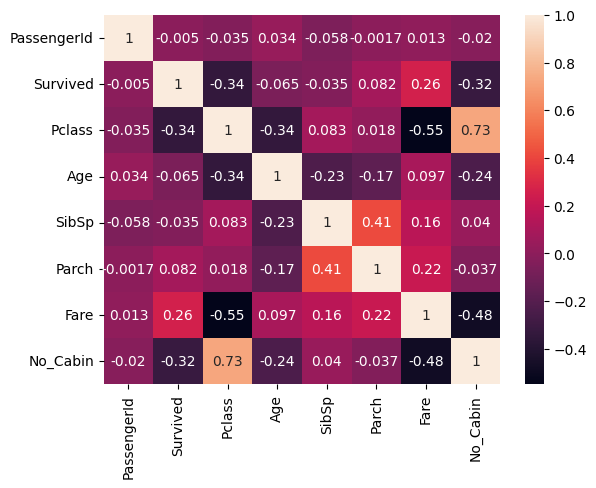

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Questions:



*   Why the diagonal contains only 1?
*   Which features correlate the most? Is it logical?
*   Can we say that if the correlation is close to 1 (or -1) that one observation depends on another?
*   Can we say that if the correlation is close to 0 there is no dependency?



Example with almost no correlation:

In [ ]:
x = np.arange(-10, 10.001, 0.01)
y = x ** 2

np.corrcoef(x, y)

array([[ 1.00000000e+00, -8.24718552e-14],
       [-8.24718552e-14,  1.00000000e+00]])

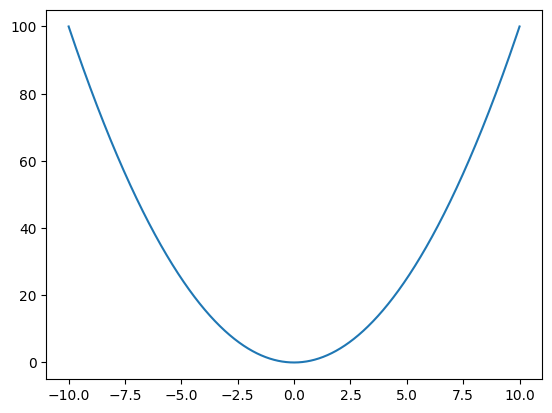

In [ ]:
plt.plot(x, y)

**Task** Create new feature `'NameLength'` that contain the length (in characters) of the name of the person. Compute the correlation table again. What can be noticed?

In [ ]:
#your code here
df['NameLength'] = df['Name'].apply(len)
df['NameLength']

,NameLength
0,23
1,51
2,22
3,44
4,24
...,...
886,21
887,28
888,40
889,21


<Axes: >

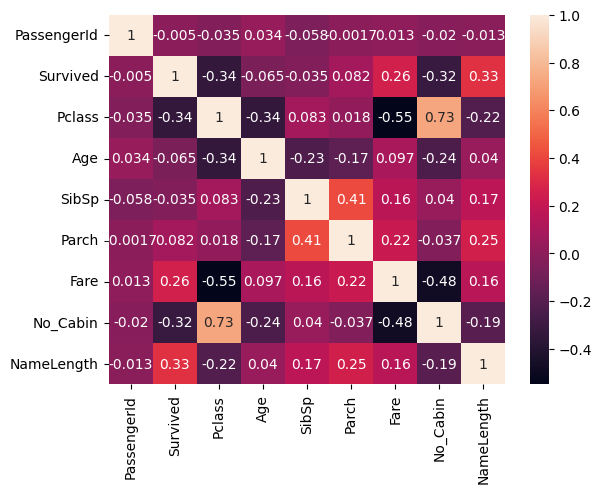

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [ ]:
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [ ]:
df.groupby('Sex')['NameLength'].mean()

,NameLength
Sex,
female,32.608280
male,23.894281


In [ ]:
df['Name']

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
...,...
886,"Montvila, Rev. Juozas"
887,"Graham, Miss. Margaret Edith"
888,"Johnston, Miss. Catherine Helen ""Carrie"""
889,"Behr, Mr. Karl Howell"


## Tasks

Athletes again

Columns :
* **ID** - Unique number for each athlete
* **Name** - Athlete's name
* **Sex** - M or F
* **Age** - Integer
* **Height** - In centimeters
* **Weight** - In kilograms
* **Team** - Team name
* **NOC** - National Olympic Committee 3-letter code
* **Games** - Year and season
* **Year** - Integer
* **Season** - Summer or Winter
* **City** - Host city
* **Sport**  - Sport
* **Event** - Event
* **Medal** - Gold, Silver, Bronze, or NA

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy import stats

In [42]:
data = pd.read_csv('https://raw.githubusercontent.com/cstorm125/information_value/master/data/120-years-of-olympic-history-athletes-and-results/athlete_events.csv')
data.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [ ]:
data.shape

(271116, 15)

**Task** Compute the range for year feature.

In [ ]:
#your code here
data['Year'].max() - data['Year'].min()

120

**Task** Compute the number of outliers (weight feature) if we filter using 3std.

In [ ]:
#your code here
mu = data['Weight'].mean()
sigma = data['Weight'].std()

right = mu + 3 * sigma
left = mu - 3 * sigma

data[(data['Weight'] < left) | (data['Weight'] > right)]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
57,18,Timo Antero Aaltonen,M,31.0,189.0,130.0,Finland,FIN,2000 Summer,2000,Summer,Sydney,Athletics,Athletics Men's Shot Put,NaN
80,22,Andreea Aanei,F,22.0,170.0,125.0,Romania,ROU,2016 Summer,2016,Summer,Rio de Janeiro,Weightlifting,Weightlifting Women's Super-Heavyweight,NaN
384,212,Yasser Abdel Rahman Sakr,M,30.0,180.0,120.0,Egypt,EGY,2008 Summer,2008,Summer,Beijing,Wrestling,"Wrestling Men's Super-Heavyweight, Greco-Roman",NaN
507,282,Hadi Abdul Jabbar,M,30.0,180.0,117.5,Iraq,IRQ,1960 Summer,1960,Summer,Roma,Weightlifting,Weightlifting Men's Heavyweight,NaN
508,282,Hadi Abdul Jabbar,M,34.0,180.0,117.5,Iraq,IRQ,1964 Summer,1964,Summer,Tokyo,Weightlifting,Weightlifting Men's Heavyweight,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270644,135357,Ji Zubrick,M,28.0,188.0,161.0,Czechoslovakia,TCH,1992 Summer,1992,Summer,Barcelona,Weightlifting,Weightlifting Men's Super-Heavyweight,NaN
270740,135401,Eurelijus ukauskas,M,22.0,218.0,115.0,Lithuania,LTU,1996 Summer,1996,Summer,Atlanta,Basketball,Basketball Men's Basketball,Bronze
270741,135401,Eurelijus ukauskas,M,27.0,218.0,115.0,Lithuania,LTU,2000 Summer,2000,Summer,Sydney,Basketball,Basketball Men's Basketball,Bronze
270742,135401,Eurelijus ukauskas,M,30.0,218.0,115.0,Lithuania,LTU,2004 Summer,2004,Summer,Athina,Basketball,Basketball Men's Basketball,NaN


**Task** Plot weight and height distribution on the same plot using z-score. Which feature has more extreme values? Make conclusions

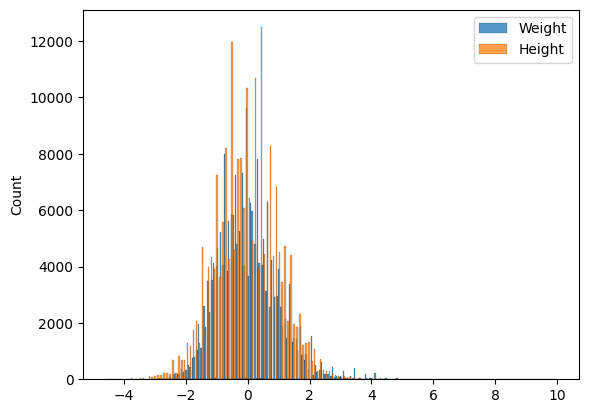

In [ ]:
#your code here
from scipy.stats import zscore

sns.histplot(zscore(data['Weight'].dropna()), label='Weight')
sns.histplot(zscore(data['Height'].dropna()), label='Height')
plt.legend();

In [ ]:
zscore(data['Weight'].dropna()).max(), zscore(data['Weight'].dropna()).min()

(np.float64(9.987297980992965), np.float64(-3.185282891885394))

In [ ]:
zscore(data['Height'].dropna()).max(), zscore(data['Height'].dropna()).min()

(np.float64(4.816402734105571), np.float64(-4.595641779939429))

In [ ]:
data[data['Weight'] == data['Weight'].max()]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
23155,12177,"Ricardo Blas, Jr.",M,21.0,183.0,214.0,Guam,GUM,2008 Summer,2008,Summer,Beijing,Judo,Judo Men's Heavyweight,NaN
23156,12177,"Ricardo Blas, Jr.",M,25.0,183.0,214.0,Guam,GUM,2012 Summer,2012,Summer,London,Judo,Judo Men's Heavyweight,NaN


**Task** Investigate correlation of numerical features. Make conclusions

<Axes: >

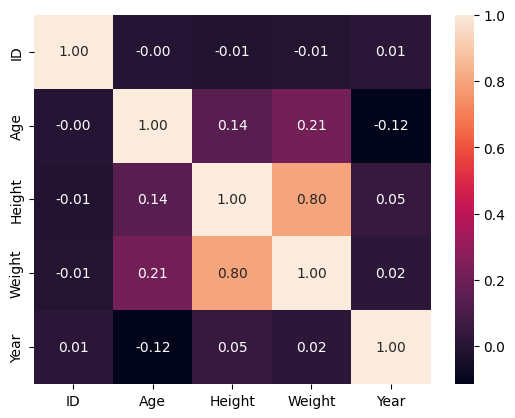

In [ ]:
#your code here
sns.heatmap(data.corr(numeric_only=True), fmt='.2f', annot=True)

**Task** Test the hypothesis that the average weight is 60 kg (the alternative is that it is not 60 kg).

In [ ]:
#your code here
from scipy.stats import ttest_1samp

result = ttest_1samp(a=data['Weight'].dropna(), popmean=60, alternative='two-sided')
result

TtestResult(statistic=np.float64(340.386272867526), pvalue=np.float64(0.0), df=np.int64(208240))

**Task** Test the hypothesis that the average weight is 60 kg (the alternative is that it is *smaller than* 60 kg).

In [5]:
#your code here
from scipy.stats import ttest_1samp

result = ttest_1samp(a=data['Weight'].dropna(), popmean=60, alternative='less')
result

TtestResult(statistic=np.float64(340.386272867526), pvalue=np.float64(1.0), df=np.int64(208240))

**Task** Test the hypothesis that there is no dependency on number of medals and the sex.

In [43]:
#your code here
medals_sex = pd.pivot_table(data, values='ID', index=['Sex'],
                       columns=['Medal'], aggfunc="count")
medals_sex

Medal,Bronze,Gold,Silver
Sex,,,
F,3771,3747,3735
M,9524,9625,9381


In [44]:
from scipy.stats import chi2_contingency

result = stats.chi2_contingency(medals_sex, correction=False)
result

Chi2ContingencyResult(statistic=np.float64(0.7370838511988413), pvalue=np.float64(0.691742207283466), dof=2, expected_freq=array([[3760.61722344, 3782.39740593, 3709.98537064],
       [9534.38277656, 9589.60259407, 9406.01462936]]))

**Task** Test the hypothesis that men and woman have the same average height.

In [18]:
#your code here

from scipy.stats import ttest_ind

result = stats.ttest_ind(a=data[(data['Sex'] == 'F')]['Height'].dropna(),
                         b=data[(data['Sex'] == 'M')]['Height'].dropna()
                         )
result

TtestResult(statistic=np.float64(-257.0759194444727), pvalue=np.float64(0.0), df=np.float64(210943.0))

**Task** Find the number of missing values in each column. Fill them with appropriate values

In [21]:
#your code here
data.isna().sum().sort_values(ascending=False)

,0
Medal,231333
Weight,62875
Height,60171
Age,9474
Sex,0
ID,0
Name,0
Team,0
NOC,0
Year,0


In [45]:
data['Medal'] = data['Medal'].fillna('No Medal')
data['Age'] = data['Age'].fillna(data['Age'].median())

#fill men and women separately
data.loc[data['Sex'] == 'F', 'Weight'] = data[data['Sex'] == 'F']['Weight'].fillna(data[data['Sex'] == 'F']['Weight'].median())
data.loc[data['Sex'] == 'M', 'Weight']  = data[data['Sex'] == 'M']['Weight'].fillna(data[data['Sex'] == 'M']['Weight'].median())

data.loc[data['Sex'] == 'F', 'Height'] = data[data['Sex'] == 'F']['Height'].fillna(data[data['Sex'] == 'F']['Height'].median())
data.loc[data['Sex'] == 'M', 'Height']  = data[data['Sex'] == 'M']['Height'].fillna(data[data['Sex'] == 'M']['Height'].median())

data.isna().sum().sort_values(ascending=False)

,0
ID,0
Name,0
Sex,0
Age,0
Height,0
Weight,0
Team,0
NOC,0
Games,0
Year,0


**Task** Test the hypothesis that probabilities to win gold/silver/bronze medals are 5%

In [39]:
#your code here
medals = data['Medal'].value_counts(normalize=True)
medals

,proportion
Medal,
No Medal,0.853262
Gold,0.049322
Bronze,0.049038
Silver,0.048378


In [46]:
from scipy.stats import chisquare

result = chisquare(f_obs = medals,
          f_exp = [0.85, 0.05, 0.05, 0.05])
result

Power_divergenceResult(statistic=np.float64(9.284753514588885e-05), pvalue=np.float64(0.9999997620628375))